In [17]:
# Load Data from Database
import pandas as pd
from database import fetch_all_data

data = fetch_all_data()

products = data["products"]
price_lists = data["price_lists"]
variants = data["variants"]
stocks = data["stocks"]

Database connection succesfull
Products loaded: 10885 rows
Price lists loaded: 14445 rows
Variants loaded: 28897 rows
Stocks loaded: 22750 rows


In [18]:
# Preview Data
print("Products")
print(products.head())

print("\nPrice Lists")
print(price_lists.head())

print("\nVariants")
print(variants.head())

print("\nStocks")
print(stocks.head())

Products
                                     id        jfsku  \
0  01967c32-83d6-76da-879c-e846d0fb1cba  VZ9N014R216   
1  b2a3a41a-5019-4d0c-8839-d9d6d9a66aa1  VZ9N01KM7J5   
2  019874c6-420d-7181-90fa-7c96e14c7e9d  VZ9N016CA6P   
3  9629bfc2-7432-11ef-af8c-db68227dcc77  VZ9N01GF587   
4  019ca18b-a795-727f-b2f4-640c120aaed1     40000012   

                                                name merchantSku     type  \
0     Trinkflasche - Topflask RCS Recycled - schwarz        4806      NaN   
1         Grußkarte - Faltkarte - DE-Studenten - Sky        1542  generic   
2                       BELLFOR Geschenkcode 15 Euro        5535      NaN   
3  Notizbuch - Classic - Leuchtturm - Softcover A...        2988      NaN   
4                                             BASICS      AR1253    stock   

  productGroup                                    netRetailPrice  \
0          NaN   {'amount': 0, 'currency': 'EUR', 'discount': 0}   
1      general   {'amount': 0, 'currency': 'EUR', 'disc

In [19]:
# Missing Values Check

print("Products missing columns:")
missing_products = products.isnull().sum()
missing_products = missing_products[missing_products > 0]
print(missing_products)





Products missing columns:
jfsku                         299
type                         4691
productGroup                 4648
deletedAt                    7988
companyId                   10541
parentId                    10097
description                   711
productColorId              10201
productMaterialId            7879
productSizeId               10267
barcode                      4978
upc                          7640
taric                        3889
originCountry                4345
taxRateId                    4978
salesUnitId                 10885
massUnitId                  10694
articleId                    5022
volume                       6068
categoryCode                 6066
numberOfPrintPositions       6072
brand                        6066
dimensions                   6098
lengthUnit                   6072
widthUnit                    6072
heightUnit                   6072
volumeUnit                   6068
grossWeightUnit              6068
netWeightUnit         

In [20]:
print("\nVariants missing columns:")
missing_price = price_lists.isnull().sum()
missing_price = missing_price[missing_price > 0]
print(missing_price)


Variants missing columns:
scale        14392
deletedAt    14377
dtype: int64


In [21]:
print("\nStocks missing columns:")
missing_variants = variants.isnull().sum()
missing_variants = missing_variants[missing_variants > 0]
print(missing_variants)


Stocks missing columns:
releaseDate           354
discontinuedDate    28895
categoryLevel3       1084
gtin                  140
pmsColor              820
deletedAt           14459
dtype: int64


In [22]:
print("\nPrice Lists missing columns:")
missing_stocks = stocks.isnull().sum()
missing_stocks = missing_stocks[missing_stocks > 0]
print(missing_stocks)


Price Lists missing columns:
firstArrivalDate        21009
firstArrivalQuantity    21009
nextArrivalDate         22390
nextArrivalQuantity     22390
deletedAt               21621
dtype: int64


In [23]:
# Check missing percentage for all tables

print("Products Missing")
missing_product = (products.isnull().sum() / len(products) * 100).round(1)
missing_product = missing_product[missing_product > 0].sort_values(ascending=False)
print(missing_product)


print("Variants Missing")
missing_variants = (variants.isnull().sum() / len(variants) * 100).round(1)
missing_variants = missing_variants[missing_variants > 0].sort_values(ascending=False)
print(missing_variants)

print("\nStocks Missing")
missing_stocks = (stocks.isnull().sum() / len(stocks) * 100).round(1)
missing_stocks = missing_stocks[missing_stocks > 0].sort_values(ascending=False)
print(missing_stocks)

print("\nPrice Lists Missing")
missing_price = (price_lists.isnull().sum() / len(price_lists) * 100).round(1)
missing_price = missing_price[missing_price > 0].sort_values(ascending=False)
print(missing_price)



Products Missing
salesUnitId                 100.0
longDescriptionDe           100.0
descriptionDe               100.0
massUnitId                   98.2
companyId                    96.8
productSizeId                94.3
productColorId               93.7
parentId                     92.8
innerCartonQuantity          86.6
deletedAt                    73.4
productMaterialId            72.4
upc                          70.2
material                     63.1
longDescription              56.2
dimensions                   56.0
numberOfPrintPositions       55.8
lengthUnit                   55.8
cartonVolume                 55.8
cartonGrossWeight            55.8
cartonHeight                 55.8
cartonWidth                  55.8
outerCartonQuantity          55.8
cartonWidthUnit              55.8
cartonHeightUnit             55.8
heightUnit                   55.8
cartonVolumeUnit             55.8
cartonLength                 55.8
cartonGrossWeightUnit        55.8
widthUnit                    55

In [24]:
# DECISION MAKING:
# If a column has more than 50% missing values, we drop it
# because it has too little data to be useful for analysis.
# If a column has less than 50% missing values, we fill it
# with a sensible default value instead of dropping it.
# Text columns → filled with 'Unknown'
# Number columns → filled with 0

print("Handling Missing Values")

# Products
# Drop columns with >50% missing 
cols_to_drop = missing_product[missing_product > 50].index.tolist() # Convert Pandas Index to normal Python list
products_clean = products.drop(columns=cols_to_drop)

# Fill remaining missing text with 'Unknown'
products_clean['description'] = products_clean['description'].fillna('Unknown')
products_clean['originCountry'] = products_clean['originCountry'].fillna('Unknown')

# Fill remaining missing numbers with 0
products_clean['weight'] = products_clean['weight'].fillna(0)
products_clean['width'] = products_clean['width'].fillna(0)
products_clean['height'] = products_clean['height'].fillna(0)
products_clean['length'] = products_clean['length'].fillna(0)
print(f"Products: dropped {len(cols_to_drop)} columns")

#  Variants
# Drop 100% and 50% missing columns
variants_clean = variants.drop(columns=['discontinuedDate', 'deletedAt'])
variants_clean['colorDescription'] = variants_clean['colorDescription'].fillna('Unknown')
variants_clean['colorGroup'] = variants_clean['colorGroup'].fillna('Unknown')
variants_clean['categoryLevel3'] = variants_clean['categoryLevel3'].fillna('Unknown')
variants_clean['pmsColor'] = variants_clean['pmsColor'].fillna('Unknown')
print("Variants: cleaned")

# Stocks
# Drop columns with >90% missing 
stocks_clean = stocks.drop(columns=['nextArrivalDate', 'nextArrivalQuantity',
                                     'deletedAt', 'firstArrivalDate',
                                     'firstArrivalQuantity'])
print("Stocks: cleaned")

#  Price Lists
# Drop columns with >90% missing 
price_lists_clean = price_lists.drop(columns=['scale', 'deletedAt'])
print("Price Lists: cleaned")

print("\nAll missing values handled!")

Handling Missing Values
Products: dropped 40 columns
Variants: cleaned
Stocks: cleaned
Price Lists: cleaned

All missing values handled!


In [25]:
# Duplicate Check
# Some columns contain dict/list type data which cannot be checked directly
# So we convert everything to string first, then check for duplicates

print("Duplicate Check")

# astype(str) converts all columns to string so we can compare rows properly
print(f"\nProducts duplicates: {products.astype(str).duplicated().sum()}")
print(f"Price Lists duplicates: {price_lists.astype(str).duplicated().sum()}")
print(f"Variants duplicates: {variants.astype(str).duplicated().sum()}")
print(f"Stocks duplicates: {stocks.astype(str).duplicated().sum()}")

Duplicate Check

Products duplicates: 0
Price Lists duplicates: 0
Variants duplicates: 0
Stocks duplicates: 0


In [26]:
# Outliers Check
# We check the price column in price_lists for unusual values
# Anything above or below 3 standard deviations is considered an outlier

import numpy as np

print("Outliers Check")

# Basic price statistics
print("\nPrice Statistics:")
print(price_lists['price'].describe())

# Calculate mean and standard deviation
mean_price = price_lists['price'].mean()
std_price = price_lists['price'].std()

# Find outliers
high_price = price_lists[price_lists['price'] > mean_price + (3 * std_price)]
low_price = price_lists[price_lists['price'] < mean_price - (3 * std_price)]

print(f"\nAverage Price: {mean_price:.2f}")
print(f"Very High Price Products: {len(high_price)}")
print(f"Very Low Price Products: {len(low_price)}")

Outliers Check

Price Statistics:
count    14445.000000
mean         4.884474
std          4.807453
min          0.040000
25%          1.830000
50%          3.070000
75%          6.650000
max         56.080000
Name: price, dtype: float64

Average Price: 4.88
Very High Price Products: 280
Very Low Price Products: 0


In [27]:
# Suspicious Data Check
# Finding products with zero or very low prices
# These could be data errors or free products

print("Suspicious Price Check")

# Products with zero price
zero_price = price_lists[price_lists['price'] <= 0]
print(f"\nProducts with zero price: {len(zero_price)}")

# Top 5 most expensive products
print("\nTop 5 Most Expensive Products:")
print(price_lists.nlargest(5, 'price')[['sku', 'price', 'currency']])

# Top 5 cheapest products
print("\nTop 5 Cheapest Products:")
print(price_lists.nsmallest(5, 'price')[['sku', 'price', 'currency']])

Suspicious Price Check

Products with zero price: 0

Top 5 Most Expensive Products:
            sku  price currency
4340  MO8384-03  56.08      EUR
3694  MO6808-03  53.95      EUR
3819  MO6870-03  47.46      EUR
2189  MO2742-03  45.32      EUR
3031  MO6194-40  44.24      EUR

Top 5 Cheapest Products:
           sku  price currency
325  KC2494-06   0.04      EUR
326  KC2494-40   0.04      EUR
921  MO2248-03   0.04      EUR
922  MO2248-06   0.04      EUR
923  MO2248-40   0.04      EUR


In [28]:
# Handle Outliers & Suspicious Data

# DECISION:
# We will NOT remove outliers or suspicious prices
# because high/low price does not always mean wrong data
# Instead we FLAG them so business can review later

# Flag high price products (Using statistics formula)
mean_price = price_lists_clean['price'].mean()
std_price = price_lists_clean['price'].std()

price_lists_clean['is_outlier'] = price_lists_clean['price'] > mean_price + (3 * std_price)
price_lists_clean['is_suspicious'] = price_lists_clean['price'] < 0.10

print(f"High price outliers flagged: {price_lists_clean['is_outlier'].sum()}")
print(f"Suspicious low price flagged: {price_lists_clean['is_suspicious'].sum()}")

High price outliers flagged: 280
Suspicious low price flagged: 31


In [34]:
# Feature Engineering

print("Feature Engineering")

# Helps identify how long a product has been in the catalogue
products_clean['createdAt'] = pd.to_datetime(products_clean['createdAt'], utc=True)
products_clean['product_age_days'] = (pd.Timestamp.now(tz='UTC') - products_clean['createdAt']).dt.days
print("Feature 1: product_age_days")

# Groups products into cheap/mid-range/expensive for easier analysis
price_lists_clean['price_category'] = pd.cut(
    price_lists_clean['price'],
    bins=[0, 5, 20, float('inf')],
    labels=['cheap', 'mid-range', 'expensive']
)
print("Feature 2: price_category")

# Quickly identifies which products are available for sale
stocks_clean['in_stock'] = stocks_clean['quantity'] > 0
print("Feature 3: in_stock")

# Shows how many products each supplier has
# Helps identify which suppliers are most active
supplier_product_count = variants_clean.groupby('productPropositionCategory')['sku'].count().reset_index()
supplier_product_count.columns = ['productPropositionCategory', 'supplier_product_count']
variants_clean = variants_clean.merge(supplier_product_count, on='productPropositionCategory', how='left')
print("Feature 4: supplier_product_count")

# Shows average price per category
# Helps identify which categories are most expensive
category_avg_price = price_lists_clean.groupby('price_category')['price'].mean().reset_index()
category_avg_price.columns = ['price_category', 'category_avg_price']
price_lists_clean = price_lists_clean.merge(category_avg_price, on='price_category', how='left')
print("Feature 5: category_avg_price")

print("\n5 Features Created Successfully!")

Feature Engineering
Feature 1: product_age_days
Feature 2: price_category
Feature 3: in_stock
Feature 4: supplier_product_count
Feature 5: category_avg_price

5 Features Created Successfully!


EDA Charts


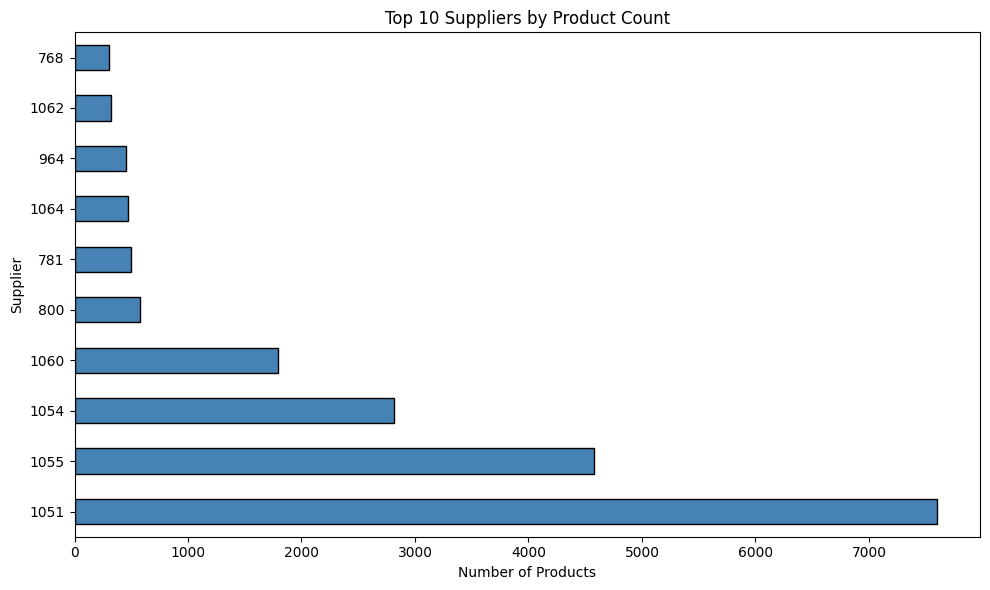

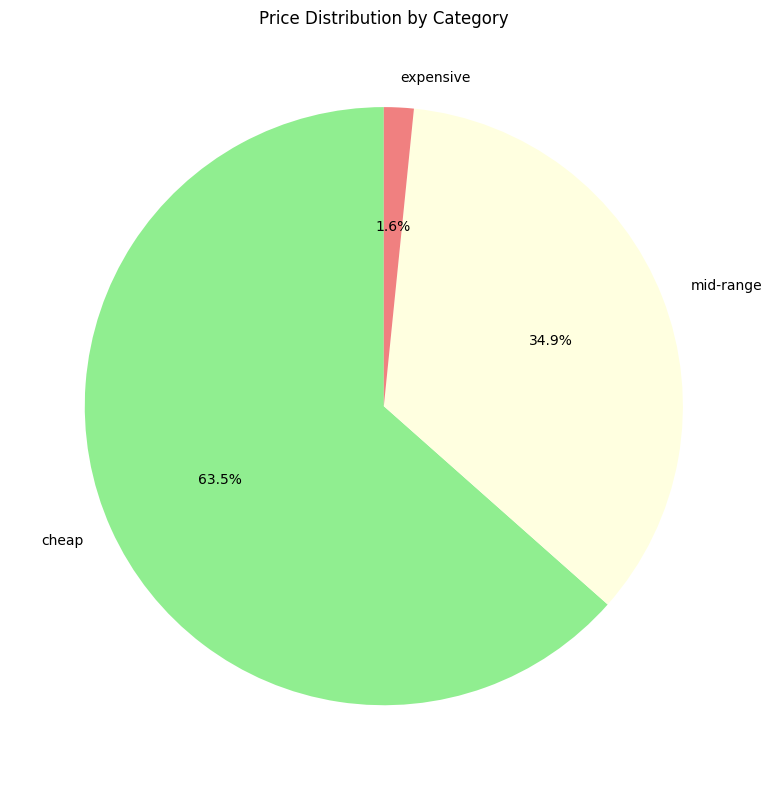

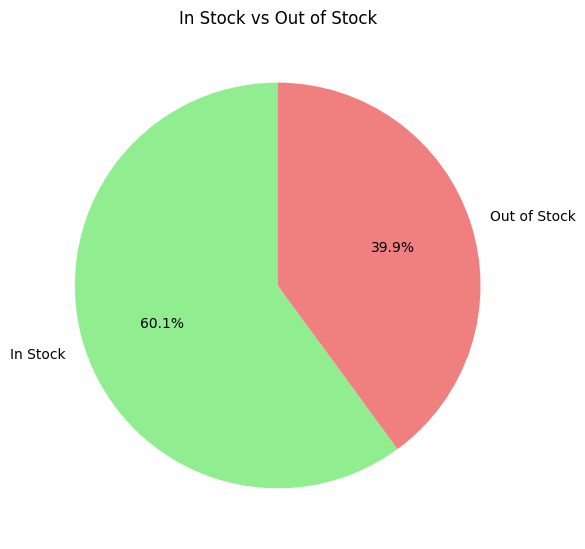

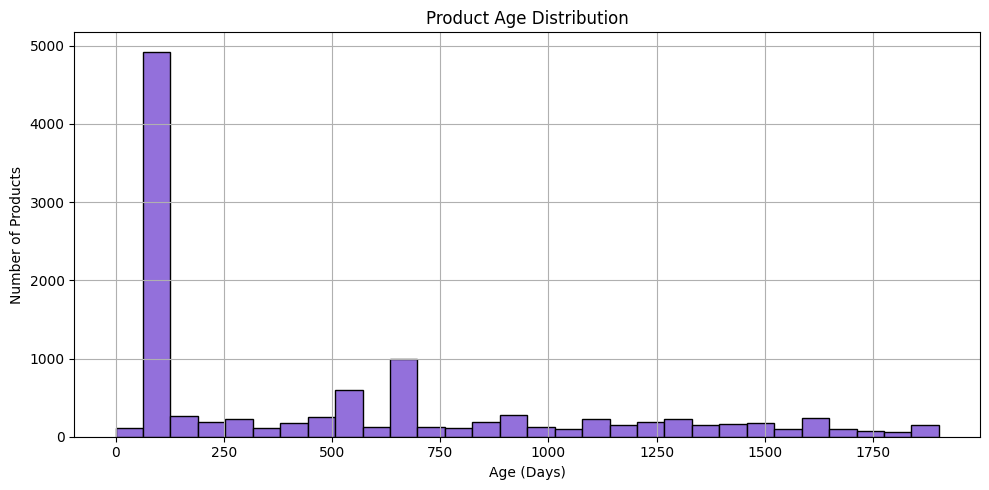

In [30]:
#EDA Charts
import matplotlib.pyplot as plt

print("EDA Charts")

# Chart 1: Which suppliers have the most products? → Horizontal Bar
plt.figure(figsize=(10, 6))
variants_clean['productPropositionCategory'].value_counts().head(10).plot(
    kind='barh',  # horizontal bar
    color='steelblue', 
    edgecolor='black'
)
plt.title('Top 10 Suppliers by Product Count')
plt.xlabel('Number of Products')
plt.ylabel('Supplier')
plt.tight_layout()
plt.savefig('output/supplier_product_count.png')
plt.show()

# Chart 2: Price Distribution across categories → Pie Chart
plt.figure(figsize=(8, 8))
price_lists_clean['price_category'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',  # show percentage
    colors=['lightgreen', 'lightyellow', 'lightcoral'],
    startangle=90
)
plt.title('Price Distribution by Category')
plt.ylabel('')
plt.tight_layout()
plt.savefig('output/price_by_category.png')
plt.show()

# Chart 3: In Stock vs Out of Stock → Pie Chart
plt.figure(figsize=(6, 6))
stocks_clean['in_stock'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightcoral'],
    labels=['In Stock', 'Out of Stock'],
    startangle=90
)
plt.title('In Stock vs Out of Stock')
plt.ylabel('')
plt.tight_layout()
plt.savefig('output/stock_status.png')
plt.show()

# Chart 4: Product Age Distribution → Histogram
plt.figure(figsize=(10, 5))
products_clean['product_age_days'].hist(
    bins=30, 
    color='mediumpurple', 
    edgecolor='black'
)
plt.title('Product Age Distribution')
plt.xlabel('Age (Days)')
plt.ylabel('Number of Products')
plt.tight_layout()
plt.savefig('output/product_age.png')
plt.show()


Supplier Segmentation
    supplier  product_count segment
0       1001              4   Small
1       1003             38   Small
2       1004             51  Medium
3       1005             14   Small
4       1006             12   Small
..       ...            ...     ...
216      994            108  Medium
217      995            106  Medium
218      997             80  Medium
219      998             14   Small
220      999             22   Small

[221 rows x 3 columns]


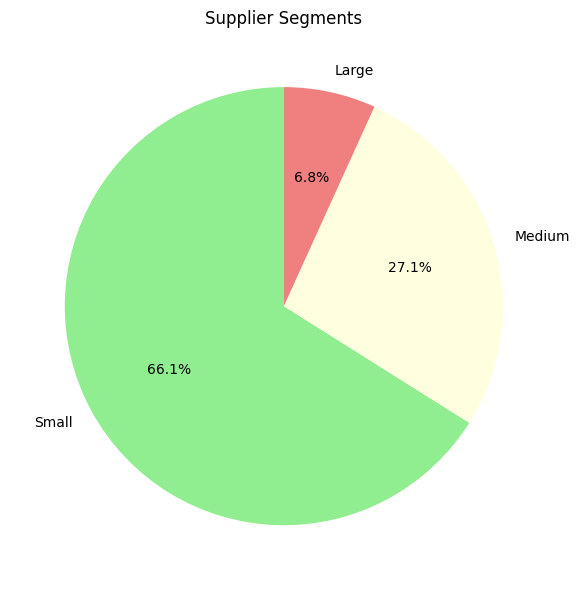

In [31]:
# Supplier Segmentation
# Grouping suppliers based on how many products they have

print("Supplier Segmentation")

# Count products per supplier
supplier_summary = variants_clean.groupby('productPropositionCategory')['sku'].count().reset_index()
supplier_summary.columns = ['supplier', 'product_count']

# Assign segment based on product count
supplier_summary['segment'] = pd.cut(
    supplier_summary['product_count'],
    bins=[0, 50, 200, float('inf')],
    labels=['Small', 'Medium', 'Large']
)

print(supplier_summary)

# Chart
plt.figure(figsize=(6, 6))
supplier_summary['segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    colors=['lightgreen', 'lightyellow', 'lightcoral'],
    startangle=90
)
plt.title('Supplier Segments')
plt.ylabel('')
plt.tight_layout()
plt.savefig('output/supplier_segments.png')
plt.show()


In [32]:
# Business Insights
# Answering key business questions from the data

print("Business Insights")

# Insight 1: Which suppliers should we prioritize?
print("\n1. Top Suppliers to Prioritize:")
top_suppliers = supplier_summary.nlargest(3, 'product_count')[['supplier', 'product_count', 'segment']]
print(top_suppliers)

# Insight 2: Pricing inconsistencies
print("\n2. Pricing Inconsistencies:")
print(f"Cheapest product:  {price_lists_clean['price'].min():.2f} EUR")
print(f"Most expensive:    {price_lists_clean['price'].max():.2f} EUR")
print(f"Average price:     {price_lists_clean['price'].mean():.2f} EUR")
print(f"High price outliers: {price_lists_clean['is_outlier'].sum()} products flagged")
print(f"Suspicious low price: {price_lists_clean['is_suspicious'].sum()} products flagged")

# Insight 3: Stock situation
print("\n3. Stock Situation:")
in_stock = stocks_clean['in_stock'].sum()
out_of_stock = (stocks_clean['in_stock']).sum()
print(f"In Stock:{in_stock} products")
print(f"Out of Stock: {out_of_stock} products")

# Insight 4: Price distribution
print("\n4. Price Distribution:")
print(price_lists_clean['price_category'].value_counts())

# Insight 5: Risks and Opportunities
print("\n5. Risks & Opportunities:")
print("Risk: 280 products have unusually high prices - needs review")
print("Risk: Some products priced at 0.04 EUR - possibly data error")
print("Opportunity: Large suppliers have high volume - good for negotiation")
print("Opportunity: Small suppliers can be grown into medium/large")



Business Insights

1. Top Suppliers to Prioritize:
   supplier  product_count segment
35     1051           7599   Large
37     1055           4576   Large
36     1054           2816   Large

2. Pricing Inconsistencies:
Cheapest product:  0.04 EUR
Most expensive:    56.08 EUR
Average price:     4.88 EUR
High price outliers: 280 products flagged
Suspicious low price: 31 products flagged

3. Stock Situation:
In Stock:13664 products
Out of Stock: 13664 products

4. Price Distribution:
price_category
cheap        9167
mid-range    5046
expensive     232
Name: count, dtype: int64

5. Risks & Opportunities:
Risk: 280 products have unusually high prices - needs review
Risk: Some products priced at 0.04 EUR - possibly data error
Opportunity: Large suppliers have high volume - good for negotiation
Opportunity: Small suppliers can be grown into medium/large


In [33]:
# Saving cleaned data to CSV files for submission

# Save cleaned products
products_clean.to_csv('output/products_clean.csv', index=False)
print("products_clean.csv saved")

# Save cleaned variants
variants_clean.to_csv('output/variants_clean.csv', index=False)
print("variants_clean.csv saved")

# Save cleaned stocks
stocks_clean.to_csv('output/stocks_clean.csv', index=False)
print("stocks_clean.csv saved")

# Save cleaned price lists
price_lists_clean.to_csv('output/price_lists_clean.csv', index=False)
print("price_lists_clean.csv saved")

# Save supplier segmentation
supplier_summary.to_csv('output/supplier_segments.csv', index=False)
print("supplier_segments.csv saved")



products_clean.csv saved
variants_clean.csv saved
stocks_clean.csv saved
price_lists_clean.csv saved
supplier_segments.csv saved
